# Spring Leaf Marketing Response

## Loading in data

In [ ]:
ls

In [307]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data

df = pd.read_csv('df_balanced.csv', low_memory = False)

In [331]:
## Data cleaning

df.shape

#checking for NA
np.any(df.isnull())
df.isna().sum().sum()

17954

In [309]:
# Removing duplicate columns in the data set

df =df.loc[:,~df.T.duplicated()]
constant_features = [col for col in df.columns if df[col].nunique() == 1]

df = df.drop(constant_features, axis = 1)

df.head()

,ID,VAR_0001,VAR_0002,VAR_0003,VAR_0004,VAR_0005,VAR_0006,VAR_0007,VAR_0014,VAR_0015,...,VAR_1926,VAR_1927,VAR_1928,VAR_1929,VAR_1930,VAR_1931,VAR_1932,VAR_1933,VAR_1934,target
0,170291,R,12,12,2500,C,2.0,2.0,2.0,1.0,...,0,1,0,999999996,400,400,9996,50,IAPS,1
1,87202,R,480,0,2400,N,0.0,0.0,0.0,0.0,...,0,1,0,999999996,400,400,9996,9,MOBILE,1
2,282584,R,14,3,3092,B,1.0,1.0,1.0,1.0,...,98,98,998,999999998,998,998,9998,9998,IAPS,1
3,45601,R,71,83,1488,C,0.0,0.0,0.0,0.0,...,98,98,998,999999998,998,998,9998,9998,BRANCH,1
4,48805,R,15,20,7000,N,2.0,1.0,1.0,2.0,...,0,1,0,999999996,400,400,9996,32,IAPS,0


In [310]:
#Spliting data into X, Y and droping ID column.

x = df.drop(['target','ID'],axis = 1)
y = df['target']
x.head()

,VAR_0001,VAR_0002,VAR_0003,VAR_0004,VAR_0005,VAR_0006,VAR_0007,VAR_0014,VAR_0015,VAR_0016,...,VAR_1925,VAR_1926,VAR_1927,VAR_1928,VAR_1929,VAR_1930,VAR_1931,VAR_1932,VAR_1933,VAR_1934
0,R,12,12,2500,C,2.0,2.0,2.0,1.0,2.0,...,2,0,1,0,999999996,400,400,9996,50,IAPS
1,R,480,0,2400,N,0.0,0.0,0.0,0.0,1.0,...,1,0,1,0,999999996,400,400,9996,9,MOBILE
2,R,14,3,3092,B,1.0,1.0,1.0,1.0,1.0,...,0,98,98,998,999999998,998,998,9998,9998,IAPS
3,R,71,83,1488,C,0.0,0.0,0.0,0.0,1.0,...,0,98,98,998,999999998,998,998,9998,9998,BRANCH
4,R,15,20,7000,N,2.0,1.0,1.0,2.0,4.0,...,1,0,1,0,999999996,400,400,9996,32,IAPS


In [311]:
#Checking data types
x.info()

#Turning int64 to float64
int_cols = x.select_dtypes(include = 'int64').columns
x[int_cols] = x[int_cols].astype('float64')

x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 1816 entries, VAR_0001 to VAR_1934
dtypes: float64(387), int64(1393), object(36)
memory usage: 13.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 1816 entries, VAR_0001 to VAR_1934
dtypes: float64(1780), object(36)
memory usage: 13.9+ MB


In [312]:
# this variable is zip codes it needs to be an object variable
x['VAR_0241'] = pd.to_numeric(df['VAR_0241'])
x['VAR_0241'] = x['VAR_0241'].astype(object)

In [313]:
#splitting Quantitative and qualitative columns
x_num = x.select_dtypes(include='float64')
x_cat = x.select_dtypes(exclude='float64')

catlist = x_cat.columns
numeric_columns = x_num.columns


In [314]:
x_cat['VAR_0241']

0      43756.0
1      78217.0
2      33544.0
3      36575.0
4      75205.0
        ...   
995    60901.0
996    31313.0
997    90746.0
998    70006.0
999    46120.0
Name: VAR_0241, Length: 1000, dtype: object

In [315]:

lower_bound = x_num.quantile(0.01)
upper_bound = x_num.quantile(0.95)

x_num = x_num.clip(lower=lower_bound, upper=upper_bound, axis=1)
numeric_columns = x_num.columns

In [316]:
x_num = x_num.dropna(axis=1, how='all') # Drop columns that are all NaNs

In [317]:
#Encoding the categorical data
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve, auc

In [318]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [319]:
cat_pipeline = Pipeline([
    ('to_str', FunctionTransformer(lambda x: x.astype(str))),
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

In [320]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, x_num.columns),
    ('cat', cat_pipeline, x_cat.columns)
])

In [321]:
x_all_array = preprocessor.fit_transform(x)
encoded_columns = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(x_cat.columns)
all_columns = list(x_num.columns) + list(encoded_columns)
x_all = pd.DataFrame(x_all_array, columns=all_columns, index=x.index)


In [322]:
selector = VarianceThreshold(threshold=0.01)
x_all = selector.fit_transform(x_all)
selected_columns = [col for col, keep in zip(all_columns, selector.get_support()) if keep]
x_all = pd.DataFrame(x_all, columns=selected_columns, index=x.index)

In [323]:
mi_scores = mutual_info_classif(x_all, y, discrete_features='auto')
mi_series = pd.Series(mi_scores, index=x_all.columns).sort_values(ascending=False)


In [324]:
x_all = x_all.drop(columns=mi_series[mi_series > 0.9].index)
x_all = x_all.drop(columns=mi_series[mi_series < 0.005].index)

In [325]:
x_all

,VAR_0003,VAR_0004,VAR_0006,VAR_0007,VAR_0014,VAR_0015,VAR_0016,VAR_0017,VAR_0033,VAR_0034,...,VAR_0353_R,VAR_0353_U,VAR_0404_CONTACT,VAR_0466_-1,VAR_0466_I,VAR_0467_Discharged,VAR_0493_-1,VAR_0493_REGISTERED NURSE,VAR_1934_BRANCH,VAR_1934_CSC
0,-0.587729,-0.136309,0.671264,1.253482,1.378000,0.416732,0.348519,0.999592,-0.141744,-0.387748,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.694793,-0.148399,-0.472117,-0.541828,-0.547345,-0.535934,-0.440984,-0.460339,0.754473,0.330917,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.668027,-0.064737,0.099574,0.355827,0.415327,0.416732,-0.440984,-0.460339,-0.141744,0.330917,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.045734,-0.258659,-0.472117,-0.541828,-0.547345,-0.535934,-0.440984,-0.460339,-0.141744,-0.387748,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-0.516353,0.407735,0.671264,0.355827,0.415327,1.369398,1.927526,0.999592,-0.141744,-0.387748,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.694793,-0.157708,-0.472117,-0.541828,-0.547345,-0.535934,-0.440984,-0.460339,-0.141744,-0.387748,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
996,-0.694793,3.551099,-0.472117,-0.541828,-0.547345,-0.535934,-0.440984,-0.460339,-0.141744,-0.387748,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
997,-0.614495,-0.172579,-0.472117,-0.541828,-0.547345,-0.535934,-0.440984,-0.460339,-0.141744,-0.387748,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
998,-0.614495,-0.072112,0.099574,0.355827,0.415327,0.416732,0.348519,0.999592,-0.141744,0.330917,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [326]:
X_train, X_val, y_train, Y_val = train_test_split(
    x_all, y, test_size = 0.2, random_state=100
)

In [327]:
def evaluate_model(model, X_val, y_val, model_name):
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    print(f"\n--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print("ROC AUC:", roc_auc_score(y_val, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
    print(classification_report(y_val, y_pred))
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
    plt.legend(loc="lower right")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()

/usr/lib/python3/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearDiscriminantAnalysis was fitted without feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearDiscriminantAnalysis was fitted without feature names
  warnings.warn(



--- Linear Discriminant Analysis ---
Accuracy: 0.545
ROC AUC: 0.5353818436592934
Confusion Matrix:
 [[36 61]
 [30 73]]
              precision    recall  f1-score   support

           0       0.55      0.37      0.44        97
           1       0.54      0.71      0.62       103

    accuracy                           0.55       200
   macro avg       0.55      0.54      0.53       200
weighted avg       0.55      0.55      0.53       200



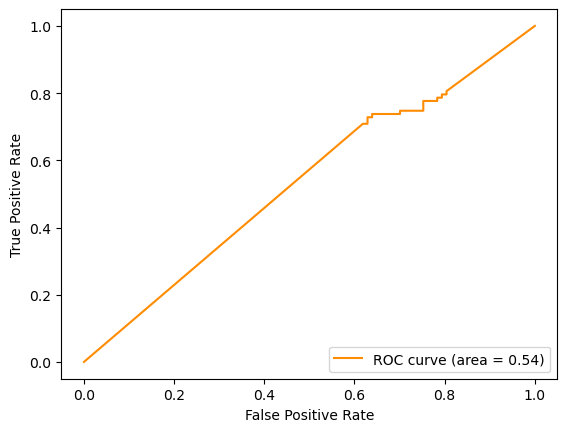

In [332]:
lda = LinearDiscriminantAnalysis(priors=[y_train.value_counts(normalize=True)[1], y_train.value_counts(normalize=True)[0]])
lda.fit(X_train_scaled, y_train)
evaluate_model(lda, X_val, Y_val, "Linear Discriminant Analysis")




--- Decision Tree ---
Accuracy: 0.68
ROC AUC: 0.717445701131018
Confusion Matrix:
 [[75 22]
 [42 61]]
              precision    recall  f1-score   support

           0       0.64      0.77      0.70        97
           1       0.73      0.59      0.66       103

    accuracy                           0.68       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.69      0.68      0.68       200



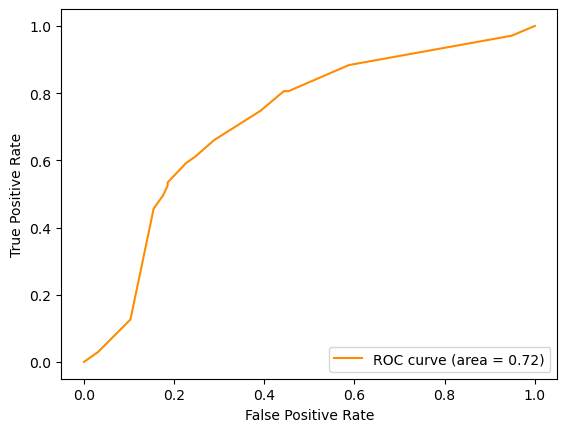

In [329]:
tree = DecisionTreeClassifier(max_depth=5, random_state=100)
tree.fit(X_train, y_train)
evaluate_model(tree, X_val, Y_val, "Decision Tree")


--- Random Forest ---
Accuracy: 0.71
ROC AUC: 0.7722450205184667
Confusion Matrix:
 [[73 24]
 [34 69]]
              precision    recall  f1-score   support

           0       0.68      0.75      0.72        97
           1       0.74      0.67      0.70       103

    accuracy                           0.71       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.71      0.71      0.71       200



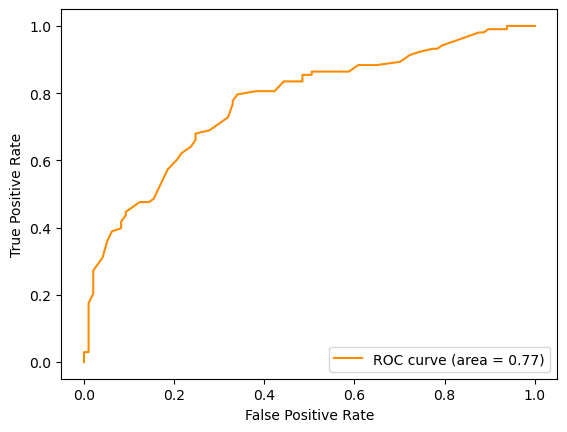

In [333]:
rf = RandomForestClassifier(class_weight='balanced', random_state=100)
rf.fit(X_train, y_train)
evaluate_model(rf, X_val, Y_val, "Random Forest")
